In [5]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

from DMeRates.DMeRate import DMeRate
import numericalunits as nu
from DMeRates.Constants import skip_keys

In [ ]:
#Fig 6 from https://arxiv.org/pdf/1703.00910

CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)


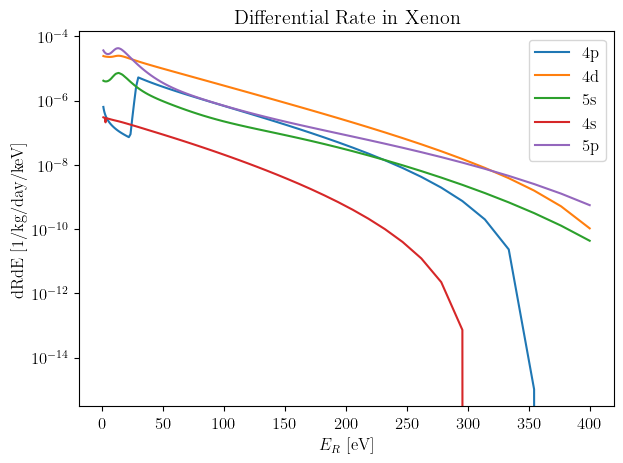

In [8]:

import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText
from matplotlib.lines import Line2D  # Required for creating custom legend entries
import numpy as np
import numericalunits as nu

#Options
params = {'text.usetex' : True,
        'font.size' : 12,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=12
material = 'Xe'
dmrates = DMeRate('Xe',form_factor_type='wimprates')


test_shell = '5p'
test_mX = 1000
test_mX_unitized = test_mX * nu.MeV / nu.c0**2
test_mX_eV = 1000*1e6

test_cs = 4e-44
FDMn = 0
halo_model = 'shm'

dmrates.update_crosssection(test_cs)

dmrates.setup_halo_data(test_mX,FDMn,'shm')

drs = dmrates.noble_dRdE(test_mX,FDMn,halo_model,halo_id_params=None,debug=False,unitize=True)
erec = dmrates.Earr.cpu().numpy() / nu.eV


for shell in dmrates.form_factor.keys:
    if shell in skip_keys[material]:
        continue
    plt.plot(erec,drs[shell].cpu().numpy(),label=f"{shell}")

plt.yscale('log')
plt.xlabel('$E_R$ [eV]')
plt.legend()
plt.ylabel("dRdE [1/kg/day/keV]")
plt.title("Differential Rate in Xenon")
plt.show()
plt.close()


<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_81801/880811666.py:4: SyntaxWarning: invalid escape sequence '\c'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_81801/880811666.py:4: SyntaxWarning: invalid escape sequence '\s'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"


took 0.12567687034606934s


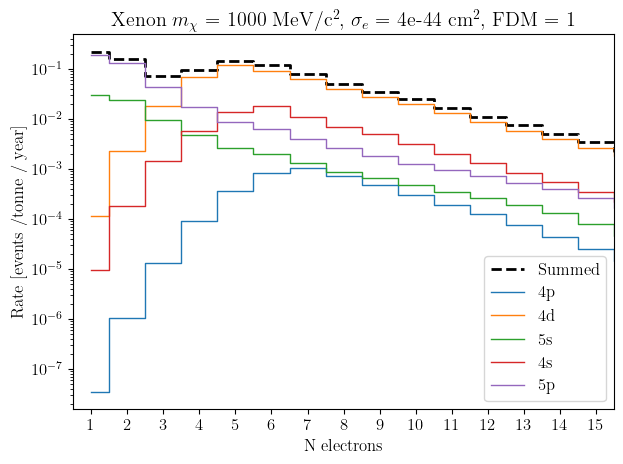

In [9]:
fdm_dict = {0: '1',
            2: '$1/q^2$'}
fdm_str = fdm_dict[FDMn]
title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}" 


plt.title('Xenon ' + title)# + (' -- SWAP 4s<->4p' if True else ''))
import time
start = time.time()
nes = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
rates_new_allsum = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=False)

rates_new_all,shells = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=True)
end = time.time()
print(f"took {end-start}s")
shells

for i,key in enumerate(shells):
        ls = '--' if i == 0 else None
        c = 'k' if i ==0 else None
        lw = 2 if i == 0 else 1
        r = rates_new_all[0][:,i] * nu.tonne * nu.year
        r = r.cpu()
        nes = nes
        plt.plot(nes,r,drawstyle='steps-mid',label=key,ls=ls,c=c,lw=lw)
plt.xticks(np.arange(1, 16))
plt.xlim(0.5, 15.5)
plt.xlabel("N electrons")
plt.legend()
plt.yscale('log')
plt.ylabel(f"Rate [events /tonne / year]")

plt.show()
plt.close()

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_81801/765251304.py:5: SyntaxWarning: invalid escape sequence '\c'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_81801/765251304.py:5: SyntaxWarning: invalid escape sequence '\s'
  title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}"


took 0.14961910247802734s


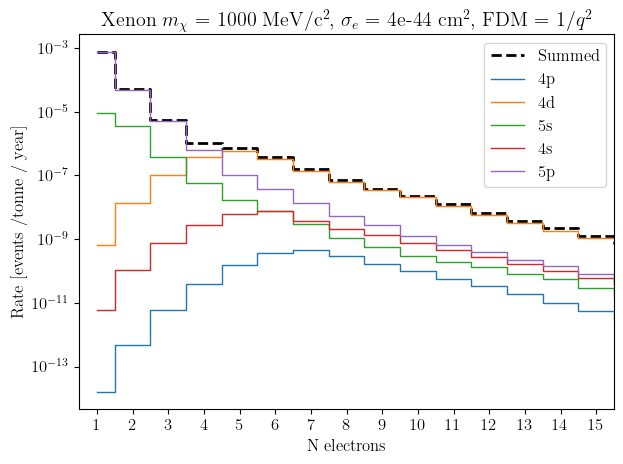

In [10]:
FDMn = 2
fdm_dict = {0: '1',
            2: '$1/q^2$'}
fdm_str = fdm_dict[FDMn]
title = f"$m_\chi$ = {test_mX} MeV/c$^2$, $\sigma_e =$ {test_cs} cm$^2$, FDM = {fdm_str}" 


plt.title('Xenon ' + title)# + (' -- SWAP 4s<->4p' if True else ''))
import time
start = time.time()
nes = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
rates_new_allsum = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=False)

rates_new_all,shells = dmrates.calculate_nobleGas_rates(test_mX,halo_model,FDMn,nes,isoangle=None,halo_id_params=None,useVerne=False,calcErrors=None,debug=False,returnShells=True)
end = time.time()
print(f"took {end-start}s")
shells

for i,key in enumerate(shells):
        ls = '--' if i == 0 else None
        c = 'k' if i ==0 else None
        lw = 2 if i == 0 else 1
        r = rates_new_all[0][:,i] * nu.tonne * nu.year
        r = r.cpu()
        nes = nes
        plt.plot(nes,r,drawstyle='steps-mid',label=key,ls=ls,c=c,lw=lw)
plt.xticks(np.arange(1, 16))
plt.xlim(0.5, 15.5)
plt.xlabel("N electrons")
plt.legend()
plt.yscale('log')
plt.ylabel(f"Rate [events /tonne / year]")

plt.show()
plt.close()